In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erfc
import csv
import time
import os


###################################################### PARAMETERS #############################################
path= "./a-b/"
p_radius = 5
p_totalTime = 2.0
p_stepTime = 10**-4
p_diffusionCoef = 79.4
p_distance = 12.5
p_nofMolecules = 10**6


normalization_parameter = 10




p_variablesx = [float(i)/5 for i in range(1,3)]
p_variablesy = [float(i)/5 for i in range(1,3)]
p_variablesz = [float(i)/5 for i in range(3,4)]
override = False

In [2]:

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("cuda" if torch.cuda.is_available() else "cpu")

# Convert parameters to tensors
radius = torch.tensor(p_radius, device=device)
totalTime = torch.tensor(p_totalTime, device=device)
stepTime = torch.tensor(p_stepTime, device=device)
diffusionCoef = torch.tensor(p_diffusionCoef, device=device)
distance = torch.tensor(p_distance, device=device)
nofMolecules = p_nofMolecules
variablesx = torch.tensor(p_variablesx)
variablesy = torch.tensor(p_variablesy)
variablesz = torch.tensor(p_variablesz)

filelist=[]

cuda


In [3]:
import torch
import os
import csv
from itertools import product
directory_list=[]


def experimenttotalsum_optimized2(radius, totalTime, stepTime, diffusionCoef, distance, nofMolecules, device):
    nofSteps = int(totalTime / stepTime) + 1

    # Create a directory name using all alfa_values
    alfa_str_list = [f"{alfax:.3f}" for alfax in constantList]
    directory_name = "alfa=" + "_".join(alfa_str_list)+"/experimental_data"
    output_directory = os.path.join(path, directory_name)
    os.makedirs(output_directory, exist_ok=True)
    directory_list.append(output_directory+"/")

    
    for alfa_value in alfa:
        nofMolecules_new = int(nofMolecules * alfa_value)

        # Initialize molecule positions and states
        positions = torch.zeros((nofMolecules_new, 3), device=device)
        positions[:, 2] = distance
        state = torch.ones(nofMolecules_new, device=device)

        # Precompute standard deviation for Gaussian noise
        sigma = torch.sqrt(2 * diffusionCoef * stepTime)
        sum_value = 0
        nofMolecules_list = torch.zeros(nofSteps, device=device)
        time_list = torch.arange(0, totalTime.item() + stepTime.item(), stepTime.item(), device=device)

        # Create a filename using alfa_value
        filenamy = f"NoDelay"
        filename = os.path.join(output_directory, filenamy + ".csv")
        filelist.append(filenamy)
        if os.path.exists(filename) and not override:
            print(f"File {filename} already exists. Skipping...")
            continue

        # Open a file to write the results
        with open(filename, "w", newline="") as file:
            writer = csv.writer(file)
            writer.writerow(["Time", "Number of Molecules"])

            for step in range(nofSteps):
                # Generate Gaussian noise for molecule movement
                noise = torch.randn_like(positions) * sigma
                positions += noise
                inside_mask = (positions.pow(2).sum(dim=1) <= radius**2) & (state > 0)
                sum_value += inside_mask.float().sum()
                state[inside_mask] = -1.0
                nofMolecules_list[step] = inside_mask.float().sum()
                writer.writerow([time_list[step].item(), nofMolecules_list[step].item()])

            # Reset positions and state for the next iteration
            positions.zero_()
            positions[:, 2] = distance
            state.fill_(1.0)

    try:
        return sum_value.item()
    except:
        return 0


In [4]:
import numpy as np
import pandas as pd
import os

def delay_and_combine(files, delays, constants , ablist,directory_list):
    if not (len(files) == len(delays) == len(constants)):
        print("Lists files, delays, and constants must be of the same length.")

    # Calculate delay times
    delayTimes = [round(p_stepTime * delay, 3) for delay in delays]

    # Load and process data
    data_list = []
    for i, (file, delay, const) in enumerate(zip(files, delays, constants)):
       
        output_directory = directory_list[0]
        file_path= output_directory + file + ".csv"
        data = np.genfromtxt(file_path, delimiter=',')

        # Check if delay exceeds data length
        if delay > len(data):
            raise ValueError(f"Delay of {delay} exceeds the length of the data in {file}.")

        # Add delay and multiply by constant
        zeros_to_prepend = np.zeros((delay, data.shape[1]))
        zeros_to_prepend[:, 0] = data[:delay, 0]
        data_delayed = np.vstack((zeros_to_prepend, data))[:len(data)]  # Truncate to original length
        data_list.append(data_delayed * [1, const])  # Apply constant only to molecule column

    # Combine data
    combined_data = sum(data_list)

    # Create DataFrame to save
    column_names = ['time', 'combined_molecules'] + [f'{file}_molecules' for file in files]
    combined_df = pd.DataFrame(np.column_stack([data_list[0][:, 0], combined_data[:, 1]] + [data[:, 1] for data in data_list]),
                               columns=column_names)

    # Save combined data to CSV
    output_file_name = '-'.join(['delay=' + str(dt) for dt in delayTimes]) + '.csv'
    combined_file = os.path.join(output_directory, output_file_name)
    combined_df.to_csv(combined_file, index=False)
    ablist.append(combined_file)

# Usage example:
# path = "/your/directory/"
# files = ['file1', 'file2', 'file3']
# delays = [10, 20, 30]
# constants = [1.5, 2.0, 0.5]
# ablist = []
# delay_and_combine(files, delays, constants, path)


In [5]:
import os
import numpy as np

def save_theoretical_data_as_csv(coef):
    # Check if the directory exists
    
    alfa_str_list = [f"{alfax:.3f}" for alfax in coef]
    directory_name = "./a-b/alfa=" + "_".join(alfa_str_list)
    output_directory2 =  directory_name + "/theoretical_data/"
    if not os.path.exists(output_directory2):
        # If the directory does not exist, create it
        os.makedirs(output_directory2)
    for i in coef:
        
        
        # Define the full path for the CSV file
        
        directory_list2.append(output_directory2)
        filelist2.append(str(i))
        csv_file_path = os.path.join(output_directory2, str(i)+".csv")
        times_for_theoretical = np.linspace(p_stepTime, p_totalTime, int(p_totalTime/p_stepTime))
        theoretical_line = analytical(p_radius, p_distance-p_radius, p_diffusionCoef, p_stepTime, int(p_nofMolecules), times_for_theoretical)
        # Prepare the data to save by combining the time and combined_molecules_data
        combined_data = np.column_stack((times_for_theoretical, theoretical_line))
        
        # Save the data to a CSV file with the specified header
        np.savetxt(csv_file_path, combined_data, delimiter=',', header='time,combined_molecules', comments='')
    


def save_binomial_data_as_csv(coef):
    # Check if the directory exists
    
    alfa_str_list = [f"{alfax:.3f}" for alfax in coef]
    directory_name = "./a-b/alfa=" + "_".join(alfa_str_list)
    output_directory3 =  directory_name + "/binomial_data/"
    if not os.path.exists(output_directory3):
        # If the directory does not exist, create it
        os.makedirs(output_directory3)
    for i in coef:
        
        
        # Define the full path for the CSV file
        
        directory_list3.append(output_directory3)
        filelist3.append(str(i))
        csv_file_path = os.path.join(output_directory3, str(i)+".csv")
        times_for_theoretical = np.linspace(p_stepTime, p_totalTime, int(p_totalTime/p_stepTime))
        theoretical_line = binomial(p_radius, p_distance-p_radius, p_diffusionCoef, p_stepTime, int(p_nofMolecules), times_for_theoretical)
        # Prepare the data to save by combining the time and combined_molecules_data
        combined_data = np.column_stack((times_for_theoretical, theoretical_line))
        
        # Save the data to a CSV file with the specified header
        np.savetxt(csv_file_path, combined_data, delimiter=',', header='time,combined_molecules', comments='')
    
        




In [6]:
from scipy.stats import binom
def Fhit_function(radius, distance, diffusionCoef, stepTime):
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * stepTime))

def analytical(radius, distance, diffusionCoef , stepTime , nofMolecules, time_values):
    Fhit_values = np.array([Fhit_function(radius, distance, diffusionCoef, t) for t in time_values])
    Fhit_shifted = np.concatenate(([0], Fhit_values[:-1]))
    return nofMolecules * (Fhit_values - Fhit_shifted)

def binomialP(radius, distance, diffusionCoef , stepTime , nofMolecules, time_values):
    Fhit_values = np.array([Fhit_function(radius, distance, diffusionCoef, t) for t in time_values])
    Fhit_shifted = np.concatenate(([0], Fhit_values[:-1]))
    return (Fhit_values - Fhit_shifted)

def binomial(radius, distance, diffusionCoef, stepTime, nofMolecules, time_values):
    # Calculate the probabilities for each time step
    probabilities = binomialP(radius, distance, diffusionCoef, stepTime, nofMolecules, time_values)

    # Simulate the binomial random variable for each time step
    binomial_results = np.random.binomial(nofMolecules, probabilities)

    return binomial_results
def sum_n_consecutive(data, n=50):
    # Assuming data is a numpy array
    n_rows = (len(data) // n) * n
    return data[:n_rows].reshape(-1, n).sum(axis=1)
def average_n_consecutive(data, n=20):
    n_rows = (len(data) // n) * n
    return data[:n_rows].reshape(-1, n).mean(axis=1)



In [25]:

############################################################## MAIN ##########################################################


#We will always choose alfa's as one they are not a parameter!!!
alfa= [1, 1, 1, 1]
#delayList=[0,400,500,900]
delayList=[0,600,4500,7500]
summary=0

#constantList=[1,-3/5,-1/4,+3/20]
constantList=[1,-0.9, 0, 0]

for i in constantList:
    summary+=abs(i)
for i in range(len(constantList)):
    constantList[i]=constantList[i]/summary
directory_list =[]
directory_list2=[]
directory_list3=[]


filelist =[]
# Call the function
start_time = time.time()
sum_value = experimenttotalsum_optimized2(radius, totalTime, stepTime, diffusionCoef, distance, nofMolecules, device)

filelist2=[]
filelist3=[]
ablist1=[]
ablist2=[]
ablist3=[]

save_theoretical_data_as_csv(constantList)
save_binomial_data_as_csv(constantList)

delay_and_combine(filelist3,delayList, constantList,ablist3,directory_list3)
delay_and_combine(filelist2,delayList, constantList,ablist2,directory_list2)
delay_and_combine(filelist,delayList, constantList,ablist1,directory_list)



end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.6f} seconds")
# Print results
print("Total Number of Molecules inside Sphere:", sum_value)

File ./a-b/alfa=0.526_-0.474_0.000_0.000/experimental_data/NoDelay.csv already exists. Skipping...
File ./a-b/alfa=0.526_-0.474_0.000_0.000/experimental_data/NoDelay.csv already exists. Skipping...
File ./a-b/alfa=0.526_-0.474_0.000_0.000/experimental_data/NoDelay.csv already exists. Skipping...
Execution time: 20.844070 seconds
Total Number of Molecules inside Sphere: 0


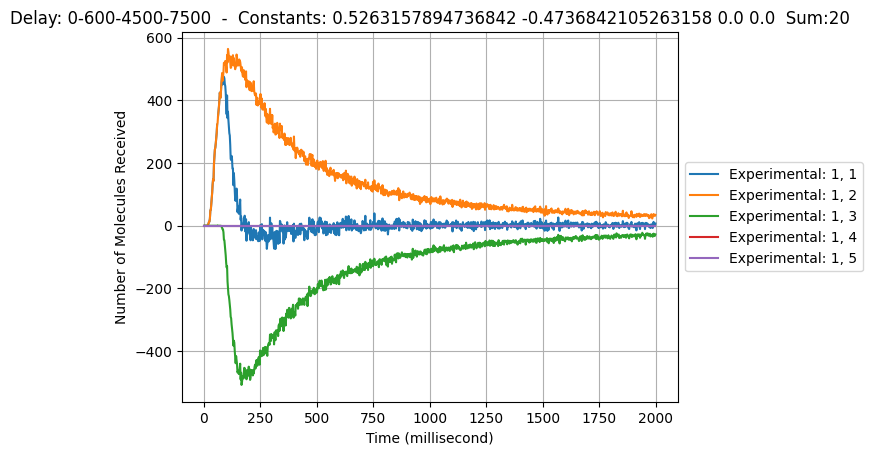

In [26]:

normalization_parameter = 20


for i, filename in enumerate(ablist1):
    output_file_name = '-'.join([f'{delay_time}' for delay_time in delayList])
    try:
        data = np.genfromtxt(filename, delimiter=',', skip_header=1)
    except:
        print("problem reading", filename)
        continue

    # Iterate over all columns except the first one (time)
    for col in range(1, data.shape[1]):
        sum_times = sum_n_consecutive(data[:, 0],normalization_parameter)*1000/normalization_parameter  # Assuming the first column is time
        sum_data = sum_n_consecutive(data[:, col],normalization_parameter)

        plt.plot(sum_times, sum_data, label=f'Experimental: {i+1}, {col}')



for i, filename in enumerate(ablist3):
    output_file_name = '-'.join([f'{delay_time}' for delay_time in delayList])
    try:
        data = np.genfromtxt(filename, delimiter=',', skip_header=1)
    except:
        print("problem reading", filename)
        continue

    # Iterate over all columns except the first one (time)
    for col in range(1, data.shape[1]):
        sum_times = sum_n_consecutive(data[:, 0],normalization_parameter)*1000/normalization_parameter  # Assuming the first column is time
        sum_data = sum_n_consecutive(data[:, col],normalization_parameter)

#        plt.plot(sum_times, sum_data, label=f'Binomial: {i+1}, {col}')




for i, filename in enumerate(ablist2):
    output_file_name = '-'.join([f'{delay_time}' for delay_time in delayList])
    try:
        data = np.genfromtxt(filename, delimiter=',', skip_header=1)
    except:
        print("problem reading", filename)
        continue

    # Iterate over all columns except the first one (time)
    for col in range(1, data.shape[1]):
        sum_times = sum_n_consecutive(data[:, 0],normalization_parameter)*1000/normalization_parameter  # Assuming the first column is time
        sum_data = sum_n_consecutive(data[:, col],normalization_parameter)

#        plt.plot(sum_times, sum_data, linestyle='--', label=f'Theoretical: {i+1}, {col}')
  

output_directory_name = '+'.join([f'{delay_time}' for delay_time in constantList])
constantsForTitle =" ".join([f'{delay_time}' for delay_time in constantList])
output =  "./plotsA-B/"+output_directory_name+"/"
if not os.path.exists(output):
    # If the directory does not exist, create it

    os.makedirs(output)
plt.title(f"Delay: {output_file_name}  -  Constants: {constantsForTitle}  Sum:{normalization_parameter}")
plt.xlabel('Time (millisecond)')
plt.ylabel('Number of Molecules Received')
plt.legend(loc='center left', bbox_to_anchor=(0.62, 0.8))  # to place the legend outside of the plot
plt.grid(True)
plt.savefig(output+output_file_name+" sum = "+str(normalization_parameter))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # to place the legend outside of the plot
plt.show()
